In [3]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Black-Scholes calculations
from scipy.stats import norm

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv(
    "nifty50_options.csv",
    engine="python",
    on_bad_lines="skip"
)
df.head()

,Date,Expiry,Strike,Type,Open,High,Low,Close,Volume,OpenInterest,Underlying
0,2021-01-01,2021-01-07,10600.0,CE,0.0,0.00,0.0,1691.80,0.0,0.0,NaN
1,2021-01-01,2021-01-07,10600.0,PE,0.8,0.85,0.3,0.35,5853.0,202425.0,NaN
2,2021-01-01,2021-01-07,10650.0,CE,0.0,0.00,0.0,1649.90,0.0,0.0,NaN
3,2021-01-01,2021-01-07,10650.0,PE,0.9,0.95,0.3,0.95,4.0,75.0,NaN
4,2021-01-01,2021-01-07,10700.0,CE,0.0,0.00,0.0,1608.50,0.0,0.0,NaN


In [11]:


# Check columns
print("Columns:")
print(df.columns.tolist())

# Convert dates
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Expiry"] = pd.to_datetime(df["Expiry"], errors="coerce")

# Convert numeric columns
for col in ["Strike", "Close"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove invalid rows
df.dropna(subset=["Date", "Expiry", "Strike", "Close"], inplace=True)

# Checks
print("\nShape after cleaning:", df.shape)
print(df.head())

print("\nMissing Values:")
print(df[["Date","Expiry","Strike","Close"]].isnull().sum())

Columns:
['Date', 'Expiry', 'Strike', 'Type', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInterest', 'Underlying']

Shape after cleaning: (2095159, 11)
        Date     Expiry   Strike Type  Open  High  Low    Close  Volume  \
0 2021-01-01 2021-01-07  10600.0   CE   0.0  0.00  0.0  1691.80     0.0   
1 2021-01-01 2021-01-07  10600.0   PE   0.8  0.85  0.3     0.35  5853.0   
2 2021-01-01 2021-01-07  10650.0   CE   0.0  0.00  0.0  1649.90     0.0   
3 2021-01-01 2021-01-07  10650.0   PE   0.9  0.95  0.3     0.95     4.0   
4 2021-01-01 2021-01-07  10700.0   CE   0.0  0.00  0.0  1608.50     0.0   

   OpenInterest  Underlying  
0           0.0         NaN  
1      202425.0         NaN  
2           0.0         NaN  
3          75.0         NaN  
4           0.0         NaN  

Missing Values:
Date      0
Expiry    0
Strike    0
Close     0
dtype: int64


In [12]:
# Create Underlying if missing
if "Underlying" not in df.columns:
    df["Underlying"] = np.nan

# Fill Underlying using median strike
df["Underlying"] = df.groupby("Date")["Strike"].transform("median")

# Constant volatility
df["Volatility"] = 0.20

# Risk-free rate
r = 0.06

# Time to expiry
df["T"] = (df["Expiry"] - df["Date"]).dt.days / 365

# Remove expired contracts
df = df[df["T"] > 0]

# Checks
print("\nUnderlying missing:", df["Underlying"].isna().sum())
print("Unique volatility:", df["Volatility"].unique())
print(df[["Date","Underlying","Volatility","T"]].head())


Underlying missing: 0
Unique volatility: [0.2]
        Date  Underlying  Volatility         T
0 2021-01-01     13350.0         0.2  0.016438
1 2021-01-01     13350.0         0.2  0.016438
2 2021-01-01     13350.0         0.2  0.016438
3 2021-01-01     13350.0         0.2  0.016438
4 2021-01-01     13350.0         0.2  0.016438


In [13]:
# Risk-free rate
r = 0.06


def bs_price(row):
    S = row["Underlying"]
    K = row["Strike"]
    T = row["T"]
    sigma = row["Volatility"]

    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if row["Type"] == "CE":
        return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    else:
        return K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)



In [14]:
# Calculate Black-Scholes prices
df["BS_Price"] = df.apply(bs_price, axis=1)

# Check results
print("BS Price Missing:", df["BS_Price"].isna().sum())
print(df[["Date", "Type", "Strike", "Underlying", "Close", "BS_Price"]].head(10))

BS Price Missing: 0
        Date Type   Strike  Underlying    Close      BS_Price
0 2021-01-01   CE  10600.0     13350.0  1691.80  2.760450e+03
1 2021-01-01   PE  10600.0     13350.0     0.35  2.733009e-18
2 2021-01-01   CE  10650.0     13350.0  1649.90  2.710499e+03
3 2021-01-01   PE  10650.0     13350.0     0.95  1.470850e-17
4 2021-01-01   CE  10700.0     13350.0  1608.50  2.660548e+03
5 2021-01-01   PE  10700.0     13350.0     0.45  7.601187e-17
6 2021-01-01   CE  10750.0     13350.0  1567.55  2.610598e+03
7 2021-01-01   PE  10750.0     13350.0   127.15  3.774187e-16
8 2021-01-01   CE  10800.0     13350.0  1527.05  2.560647e+03
9 2021-01-01   PE  10800.0     13350.0     0.40  1.801498e-15


In [15]:
# Error metrics
df["Error"] = df["BS_Price"] - df["Close"]
df["Absolute_Error"] = abs(df["Error"])
df["Squared_Error"] = df["Error"]**2

# Metrics
mae = df["Absolute_Error"].mean()
rmse = np.sqrt(df["Squared_Error"].mean())

print("Mean Absolute Error (MAE):", round(mae, 4))
print("Root Mean Square Error (RMSE):", round(rmse, 4))

# Sample comparison
print(df[["Date","Type","Strike","Close","BS_Price","Error"]].head(10))

Mean Absolute Error (MAE): 374.3452
Root Mean Square Error (RMSE): 667.608
        Date Type   Strike    Close      BS_Price        Error
0 2021-01-01   CE  10600.0  1691.80  2.760450e+03  1068.649640
1 2021-01-01   PE  10600.0     0.35  2.733009e-18    -0.350000
2 2021-01-01   CE  10650.0  1649.90  2.710499e+03  1060.598931
3 2021-01-01   PE  10650.0     0.95  1.470850e-17    -0.950000
4 2021-01-01   CE  10700.0  1608.50  2.660548e+03  1052.048222
5 2021-01-01   PE  10700.0     0.45  7.601187e-17    -0.450000
6 2021-01-01   CE  10750.0  1567.55  2.610598e+03  1043.047513
7 2021-01-01   PE  10750.0   127.15  3.774187e-16  -127.150000
8 2021-01-01   CE  10800.0  1527.05  2.560647e+03  1033.596803
9 2021-01-01   PE  10800.0     0.40  1.801498e-15    -0.400000


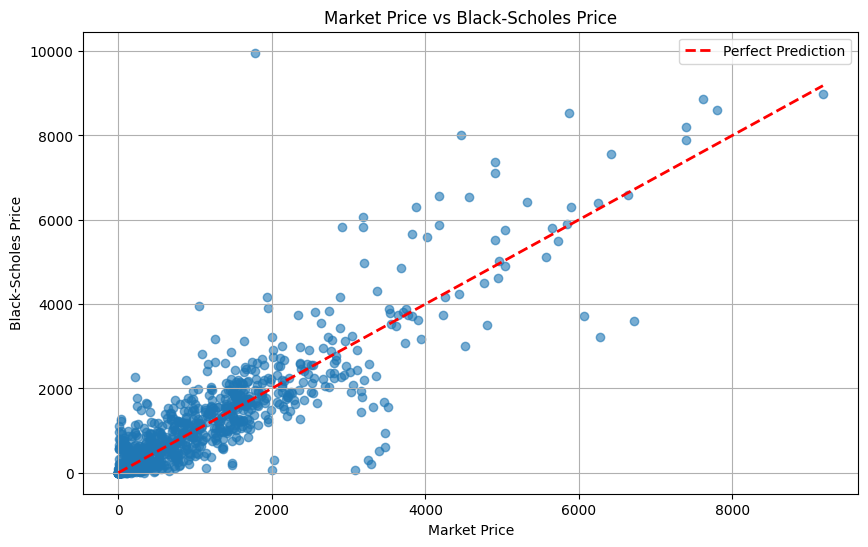

In [17]:

# Take a sample
plot_df = df.sample(1000, random_state=42)

plt.figure(figsize=(10,6))
plt.scatter(plot_df["Close"], plot_df["BS_Price"], alpha=0.6)
plt.plot(
    [plot_df["Close"].min(), plot_df["Close"].max()],
    [plot_df["Close"].min(), plot_df["Close"].max()],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Market Price")
plt.ylabel("Black-Scholes Price")
plt.title("Market Price vs Black-Scholes Price")
plt.legend()
plt.grid(True)

plt.show()

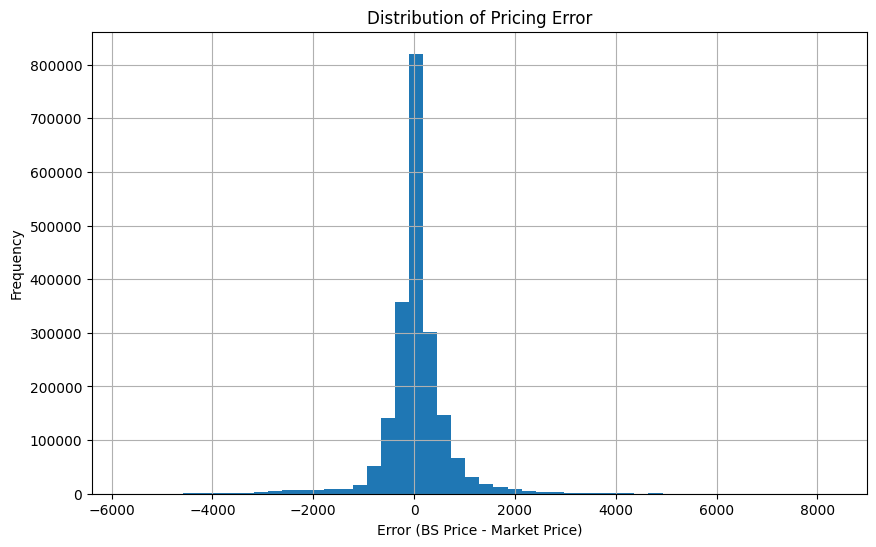

In [18]:
plt.figure(figsize=(10,6))

plt.hist(df["Error"], bins=50)

plt.title("Distribution of Pricing Error")
plt.xlabel("Error (BS Price - Market Price)")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

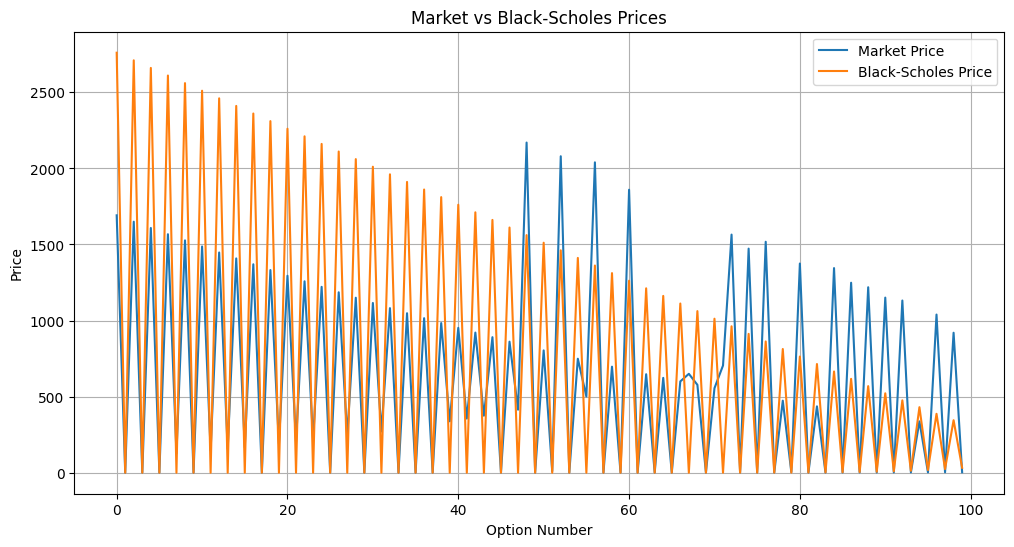

In [20]:
sample = df.head(100)

plt.figure(figsize=(12,6))

plt.plot(sample["Close"].values, label="Market Price")
plt.plot(sample["BS_Price"].values, label="Black-Scholes Price")

plt.title("Market vs Black-Scholes Prices")
plt.xlabel("Option Number")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()